In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from scipy.interpolate import griddata
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) # Suppresses the massive wall of text
from sklearn.metrics import mean_absolute_error


warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')


In [9]:

# 1. Load Data
df = pd.read_csv("./data/df_features.csv")
df['trading_date'] = pd.to_datetime(df['trading_date'])
df = df.sort_values('trading_date').reset_index(drop=True)
df = df[(df['trading_date'] >= '2021-01-01') & (df['trading_date'] < '2026-03-26')].reset_index(drop=True).copy()

In [ ]:




class VolatilityRiskPipeline:
    """
    End-to-End Quantitative Pipeline for 21-Day Forward Volatility Prediction.
    Includes Categorical EDA, Walk-Forward Validation, LightGBM Modeling, and SHAP Interpretability.
    """
    
    def __init__(self, df: pd.DataFrame, target_col: str = 'target_vol_21d', date_col: str = 'trading_date',test_size=0.10):
        
        # Ensure chronological order (Critical for Time-Series)
        self.df = df.copy()
        self.df[date_col] = pd.to_datetime(self.df[date_col])
        self.df = self.df.sort_values(date_col).reset_index(drop=True)
        
        self.target = target_col
        self.date_col = date_col
        self.model = None
        self.explainer = None
        
        split_idx = int(len(self.df) * (1 - test_size))
        self.train_val_df = self.df.iloc[:split_idx].reset_index(drop=True)
        
        self.test_df = self.df.iloc[split_idx:].reset_index(drop=True)
        self.train_val_df.to_csv('./data/train_val.csv',index=False)
        self.test_df.to_csv('./data/test.csv',index=False)
        print(f" Data Split Complete:")
        print(f"   Train/Val Set: {len(self.train_val_df)} days (Ends: {self.train_val_df[date_col].max().date()})")
        print(f"   Holdout Test Set: {len(self.test_df)} days (Starts: {self.test_df[date_col].min().date()})")
        
        # ---------------------------------------------------------
        # THE FEATURE TAXONOMY
        # ---------------------------------------------------------
        self.feature_groups = {
                        "Price_Dynamics": ['vol_rolling_21d', 'msft_return', 'dist_from_ma200', 'vol_garman_klass', ],
                        
                        "Macro_Regime": ['vix_level', 'vix_5d_trend', 'yield_10y_level', 'yield_10y_delta_5d','qqq_vol_21d','vol_surge'],
                        
                        "NLP_Sentiment": ["prepped_sentiment","MDA_Dispersion","prepped_dispersion", "prepped_neutral","qa_sentiment", "qa_dispersion", "qa_neutral","Risk_Combined_Mean",\
                                            "MDA_Neutrality","Risk_Combined_Std","Risk_Combined_Neutrality","MDA_Delta","MDA_Sentiment","Risk_Delta"],
                        
                        "Fundamental_Accounting": ['roa', 'debt_to_asset', 'fcf_margin', 'net_income_qoq', 'cash_coverage'],
                        
                        "Temporal": ['days_since_earnings', 'days_since_filing']
}        
        # Flatten for model training
        self.all_features = [feat for group in self.feature_groups.values() for feat in group]

    def set_active_features(self, custom_feature_list: list):
        """
        Surgically prunes the feature space to prevent dimensionality noise.
        Overrides the default 'all_features' list initialized in the class.
        """
        old_count = len(self.all_features)
        new_count = len(custom_feature_list)
        
        # Validation check: Ensure the core price features still exist so the Baseline model doesn't crash
        core_price = self.feature_groups["Price_Dynamics"]
        missing_core = [f for f in core_price if f not in custom_feature_list]
        if missing_core:
            print(f"Warning: You pruned core baseline features: {missing_core}. The Baseline model may fail.")
            
        self.all_features = custom_feature_list
        print(f"Feature Space Pruned: Reduced from {old_count} down to {new_count} high-conviction features.")
    
    
    def optimize_lgbm_hyperparameters(self, n_trials: int = 30, n_splits: int = 5):
        """
        Uses Bayesian Optimization to find the optimal regularization parameters 
        for the LightGBM model without exhaustive Grid Search.
        """
        print(f"\n Launching Optuna Bayesian Optimization ({n_trials} Trials)...")
        print("Target: Maximizing Shrinkage & Regularization on Walk-Forward CV")
        
        # We only tune on the Train/Val set!
        X = self.train_val_df[self.all_features]
        y = self.train_val_df[self.target]
        tscv = TimeSeriesSplit(n_splits=n_splits)

        def objective(trial):
            # 1. Define the Search Space (Strictly constrained for small datasets)
            param_grid = {
                'objective': 'regression',
                'metric': 'rmse',
                'verbosity': -1,
                'seed': 42,
                
                # The "Shrinkage" Parameters Optuna will tweak:
                'max_depth': trial.suggest_int('max_depth', 3, 6),
                'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
                'subsample': trial.suggest_float('subsample', 0.6, 1),
                'num_leaves': trial.suggest_int('num_leaves', 7, 31),
                'min_child_samples': trial.suggest_int('min_child_samples', 15, 80),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True) # L2
            }

            cv_scores = []
            
            # 2. Evaluate this specific parameter combination using Walk-Forward CV
            for train_idx, val_idx in tscv.split(X):
                X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
                X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

                model = lgb.LGBMRegressor(**param_grid, n_estimators=2000)
                callbacks = [lgb.early_stopping(stopping_rounds=25, verbose=False)]

                model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=callbacks
                )

                preds = model.predict(X_val)
                rmse = np.sqrt(mean_squared_error(y_val, preds))
                cv_scores.append(rmse)

            # Optuna's goal is to minimize this average out-of-sample RMSE
            return np.mean(cv_scores)

        # 3. Run the Optimization
        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=n_trials)

        print("\nOPTIMIZATION COMPLETE ")
        print(f"Best Out-of-Sample CV RMSE: {study.best_value:.4f}")
        print("Best Parameters Found:")
        for key, value in study.best_params.items():
            if isinstance(value, float):
                print(f"   {key}: {value:.4f}")
            else:
                print(f"   {key}: {value}")
                
        return study.best_params
        
    def compare_model_progression(self, n_splits: int = 5,tuned_params:dict=None):
        """
        Executes Walk-Forward Validation across 3 distinct tiers to prove Alpha generation:
        1. Naive Baseline (Pure Autoregressive Math)
        2. Price-Only LightGBM (Standard Quant Model)
        3. Full Alpha LightGBM (Custom NLP + Macro)
        """
        
        
        print(f"Executing Walk-Forward Validation ({n_splits} Folds)...")
        
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        # Trackers for our 3 models
        naive_scores = []
        price_scores = []
        alpha_scores = []
        
        # Define the subset for the Price-Only baseline
        price_features = self.feature_groups["Price_Dynamics"]
        
        X = self.train_val_df[self.all_features]
        y = self.train_val_df[self.target]
        
        # Institutional constraints to prevent overfitting
    
        params = {
            'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.01,"num_threads":6,"n_estimators": 2000,\
                "max_depth": 5,"min_samples_leaf": 30, "colsample_bytree": 0.6,  'reg_lambda':1 , \
            'verbosity': -1, 'seed': 42
        }
        callbacks = [lgb.early_stopping(stopping_rounds=15, verbose=True)]

        if tuned_params:
            params.update(tuned_params)
        else:
            
            for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
                X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
                X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
                
                # --------------------------------------------------
                # TIER 1: Naive Baseline (Math Only)
                # Assumption: Future volatility equals historical rolling volatility
                # --------------------------------------------------
                naive_preds = X_val['vol_rolling_21d']
                naive_rmse = np.sqrt(mean_squared_error(y_val, naive_preds))
                naive_scores.append(naive_rmse)
                
                
                # --------------------------------------------------
                # TIER 2: Price-Only LightGBM
                # --------------------------------------------------
                model_price = lgb.LGBMRegressor(**params)
                model_price.fit(
                    X_train[price_features], y_train,
                    eval_set=[(X_val[price_features], y_val)],
                    callbacks=callbacks
                )
                price_preds = model_price.predict(X_val[price_features])
                price_rmse = np.sqrt(mean_squared_error(y_val, price_preds))
                price_scores.append(price_rmse)
                
                # --------------------------------------------------
                # TIER 3: The Alpha Model (Full Feature Space)
                # --------------------------------------------------
                model_alpha = lgb.LGBMRegressor(**params)
                model_alpha.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=callbacks
                )
                alpha_preds = model_alpha.predict(X_val)
                alpha_rmse = np.sqrt(mean_squared_error(y_val, alpha_preds))
                alpha_scores.append(alpha_rmse)
                
                print(f"Fold {fold+1} | Naive: {naive_rmse:.4f} | Price-LGBM: {price_rmse:.4f} | Alpha-LGBM: {alpha_rmse:.4f}")
            
        # Calculate final averages
        avg_naive = np.mean(naive_scores)
        avg_price = np.mean(price_scores)
        avg_alpha = np.mean(alpha_scores)
        
        print("\n" + "="*50)
        print("🏆 FINAL OUT-OF-SAMPLE RMSE RESULTS")
        print("="*50)
        print(f"1. Naive Baseline (Autoregressive):  {avg_naive:.4f}")
        print(f"2. Price-Only LightGBM:              {avg_price:.4f}")
        print(f"3. Full Alpha LightGBM (NLP+Macro):  {avg_alpha:.4f}")
        
        alpha_value = ((avg_price - avg_alpha) / avg_price) * 100
        print(f"\n💡 Alpha Value Add: Unstructured features improved the ML baseline by {alpha_value:.2f}%.")
        
        # Save the final alpha model to the class instance for SHAP later
        final_model = lgb.LGBMRegressor(**params)
        final_model.fit(X, y)
        self.model = final_model
        self.plot_model_progression(avg_naive, avg_price, avg_alpha,X,y)

    def plot_model_progression(self, avg_naive, avg_price, avg_alpha,X,y):
        """Generates the 'Mic Drop' bar chart for the presentation slide."""
        print("\n--- SANITY CHECK: TARGET VARIANCE MISMATCH ---")
        print(f"Train Set Target Mean: {self.train_val_df[self.target].mean():.4f} | Std Dev (Chaos): {self.train_val_df[self.target].std():.4f}")
        print(f"Test Set Target Mean:  {self.test_df[self.target].mean():.4f} | Std Dev (Chaos): {self.test_df[self.target].std():.4f}")
        plt.figure(figsize=(10, 6))
        
        models = ['1. Naive Baseline\n(Rolling Vol)', '2. Price-Only LGBM\n(Technical Quant)', '3. The Alpha Model\n(NLP + Macro + Price)']
        scores = [avg_naive, avg_price, avg_alpha]
        colors = ['#d3d3d3', '#8faadc', '#2e5597'] # Grey, Light Blue, Deep Corporate Blue
        
        bars = plt.bar(models, scores, color=colors, width=0.6)
        
        plt.ylabel('Out-of-Sample RMSE (Lower is Better)')
        plt.title('Model Progression: Isolating the Alpha Value Add', pad=20, fontsize=14, fontweight='bold')
        
        # Add data labels on top of bars
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
            
        # Draw an arrow showing the Alpha Drop
        plt.annotate(
            '', xy=(2, avg_alpha), xytext=(1, avg_price),
            arrowprops=dict(arrowstyle="->", color="red", lw=2, ls='--')
        )
        plt.text(1.5, (avg_price+avg_alpha)/2 + 0.002, 'Value Add\nof NLP', color='red', ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()
        explainer = shap.TreeExplainer(self.model)
        shap_values_obj = explainer(X)
        
        # 4. Generate the Pruning Bar Chart
        plt.figure(figsize=(10, 8))
        
        # shap.plots.bar automatically calculates the mean absolute SHAP value
        shap.plots.bar(shap_values_obj, max_display=30, show=False)
        
        plt.title("Feature Pruning: Mean Absolute SHAP (Train/Val Data)", pad=20, fontweight='bold')
        plt.xlabel("Mean Absolute Impact on Predicted Volatility")
        plt.tight_layout()
        plt.show()
    
    
    
    # ==========================================
    # PHASE 3: INTERPRETABILITY (SHAP)
    # ==========================================
    def generate_shap_explanations(self):
        """Extracts native feature importance and directional SHAP values."""
        if self.model is None:
            raise ValueError("Model must be trained before generating SHAP values.")
            
        print(" Extracting Model Interpretability...")
        X = self.test_df[self.all_features]
        
        
        self.explainer = shap.TreeExplainer(self.model)
        shap_values = self.explainer(X)
        
        plt.figure(figsize=(10, 6))
        plt.title("SHAP Beeswarm Plot: Feature Directionality")
        shap.plots.beeswarm(shap_values, max_display=12, show=False)
        plt.tight_layout()
        plt.show()
        
    def generate_local_waterfall_plot(self, index: int):
        """Generates a local explanation for a specific trading day."""
        if self.explainer is None:
            raise ValueError("Run generate_shap_explanations() first to initialize SHAP.")
            
        X = self.test_df[self.all_features]
        date = self.test_df.loc[index, self.date_col].strftime('%Y-%m-%d')
        actual_vol = self.test_df.loc[index, self.target]
        
        # 1. Extract the row as a 2D DataFrame for the model and SHAP math
        row_2d = X.iloc[[index]]
        
        # 2. Extract the row as a 1D Series for the plot labels
        row_1d = X.iloc[index]
        
        predicted_vol = self.model.predict(row_2d)[0]
        
        print(f"Trading Date: {date}")
        print(f"Actual Volatility: {actual_vol:.4f} | Predicted Volatility: {predicted_vol:.4f}")
        

        shap.initjs()
        # Pass the 2D DataFrame to calculate SHAP values
        shap_values = self.explainer(X)
        shap.force_plot(self.explainer.expected_value, shap_values.values[0, :], X.iloc[index, :],matplotlib=True)

    def evaluate_on_test_set(self):
        """
        Unlocks the holdout Test Set to calculate the final, true out-of-sample 
        institutional metrics (RMSE, Hit Rate, Tail-RMSE) for the deployment decision.
        """
        if self.model is None:
            raise ValueError("You must run compare_model_progression() to train the model first.")
            
        print("\n" + "="*50)
        print("🚨 UNLOCKING THE VAULT: FINAL TEST SET EVALUATION 🚨")
        print("="*50)

        # X and y for the unseen Test Set
        X_test = self.test_df[self.all_features]
        y_test = self.test_df[self.target]
        
        # Predict on the unseen data
        preds = self.model.predict(X_test)
        
        # --------------------------------------------------
        # 1. Global RMSE & Mean Error
        # --------------------------------------------------
        test_rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_mae = mean_absolute_error(y_test, preds)
        mean_error = np.mean(preds - y_test)
        
        print(f"1. Final Test RMSE:           {test_rmse:.4f}")
        print(f"2. Systematic Bias:           {mean_error:.4f} "
              f"({'Under-predicting' if mean_error < 0 else 'Over-predicting'} risk)")
        print(f"3. Final Test MAE:            {test_mae:.4f}")
        
        plt.figure(figsize=(12, 6))
        
        # Plot the lines
        plt.plot(self.test_df['trading_date'], self.test_df[self.target], label='Actual 21-Day Volatility', color='#d3d3d3', linewidth=2)
        plt.plot(self.test_df['trading_date'], preds, label='Predicted Risk (Alpha Model)', color='#2e5597', linewidth=2)
        
        plt.title('Out-of-Sample Tracking: Predicted vs. Actual Risk', fontweight='bold', pad=15)
        plt.ylabel('Annualized Volatility')
        plt.xlabel('Trading Date')
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(8, 5))
        
        er = preds - y_test
        # Plot the histogram of errors
        plt.hist(er, bins=30, color='#2e5597', alpha=0.7, edgecolor='white')
        
        # Draw the "Danger Line" (Zero error)
        plt.axvline(0, color='black', linestyle='-', linewidth=2, label='Zero Error (Perfect Match)')
        
        # Draw the Model's actual bias
        plt.axvline(mean_error, color='#d9534f', linestyle='--', linewidth=2, label=f'Mean Bias (+{mean_error:.4f})')
        
        plt.title('Out-of-Sample Error Distribution (Residuals)', fontweight='bold', pad=15)
        plt.xlabel('Prediction Error (Predicted - Actual)')
        plt.ylabel('Frequency (Days)')
        
        # Add a text box explaining the safety buffer
        plt.text(0.05, 0.95, 'Positive Error = Conservative (Safe)\nNegative Error = Under-hedged (Danger)', 
                 transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.legend()
        plt.tight_layout()
        plt.show()

        # --------------------------------------------------
        # 2. Tail-RMSE (Crisis Performance on Unseen Data)
        # --------------------------------------------------
        threshold_90 = np.percentile(y_test, 90)
        tail_idx = y_test >= threshold_90
        
        tail_rmse = np.sqrt(mean_squared_error(y_test[tail_idx], preds[tail_idx]))
        print(f"3. Tail-RMSE (Top 10% events): {tail_rmse:.4f}")

        # --------------------------------------------------
        # 3. Directional Hit Rate
        # --------------------------------------------------
        current_vol = self.test_df['vol_rolling_21d']
        actual_direction = np.sign(y_test - current_vol)
        predicted_direction = np.sign(preds - current_vol)
        
        hit_rate = np.mean(actual_direction == predicted_direction) * 100
        print(f"4. Directional Hit Rate:      {hit_rate:.2f}%")
        
        print("5. Generating Out-of-Sample Calibration Plot (Quintiles)...")
        
        calib_df = pd.DataFrame({'Actual': y_test, 'Predicted': preds})
        
        # Downgraded to 5 buckets (Quintiles) to ensure statistical significance on a small test set
        calib_df['Quintile'] = pd.qcut(calib_df['Predicted'].rank(method='first'), q=5, labels=False) + 1
        
        quintile_stats = calib_df.groupby('Quintile').mean()

        plt.figure(figsize=(8, 5))
        x = np.arange(5)
        width = 0.35

        plt.bar(x - width/2, quintile_stats['Predicted'], width, label='Avg Predicted Volatility', color='#2e5597')
        plt.bar(x + width/2, quintile_stats['Actual'], width, label='Avg Actual Volatility', color='#d3d3d3')

        plt.xlabel('Predicted Risk Quintile (1 = Lowest, 5 = Highest Risk)', fontweight='bold')
        plt.ylabel('Annualized Volatility', fontweight='bold')
        plt.title('TRUE OUT-OF-SAMPLE CALIBRATION\n(Holdout Test Set - Quintile Resolution)', pad=15)
        plt.xticks(x, ['Q1 (Safe)', 'Q2', 'Q3', 'Q4', 'Q5 (Danger)'])
        plt.legend()
        plt.tight_layout()
        plt.show()
# ==========================================
# EXECUTION SCRIPT
# ==========================================


In [ ]:
# if __name__ == "__main__":
# Assume 'train_df' is your fully engineered dataframe
pipeline = VolatilityRiskPipeline(df)

pruned_features = [
        # The Core Baseline (Do not remove these, the Tier 2 model needs them)
        'vol_rolling_21d', 
        'msft_return', 
        'dist_from_ma200', 
        'vol_garman_klass',         
        # The Proven Alpha (Your Top 3 non-price features from SHAP)
        'qa_dispersion',
        'vix_level',
        'fcf_margin',
        'yield_10y_level',
        'prepped_neutral',
        'days_since_earnings',
        'cash_coverage','qqq_vol_21d',
        'qa_sentiment',
        'qa_neutral',
    ]
    

    # 3. Execute the Pruning
# pipeline.set_active_features(pruned_features)
# 2. Model Development & Validation



 Data Split Complete:
   Train/Val Set: 1180 days (Ends: 2025-09-15)
   Holdout Test Set: 132 days (Starts: 2025-09-16)


Executing Walk-Forward Validation (5 Folds)...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[269]	valid_0's rmse: 0.118103
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.143925
Fold 1 | Naive: 0.0717 | Price-LGBM: 0.1181 | Alpha-LGBM: 0.1439
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[117]	valid_0's rmse: 0.0815031
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[89]	valid_0's rmse: 0.0860741
Fold 2 | Naive: 0.1015 | Price-LGBM: 0.0815 | Alpha-LGBM: 0.0861
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[198]	valid_0's rmse: 0.0534771
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[350]	valid_0's rmse: 0.0588913
Fold 3 | Naive: 0.0548 | Price-LGBM: 0.0535 | Alpha-LGBM: 0.

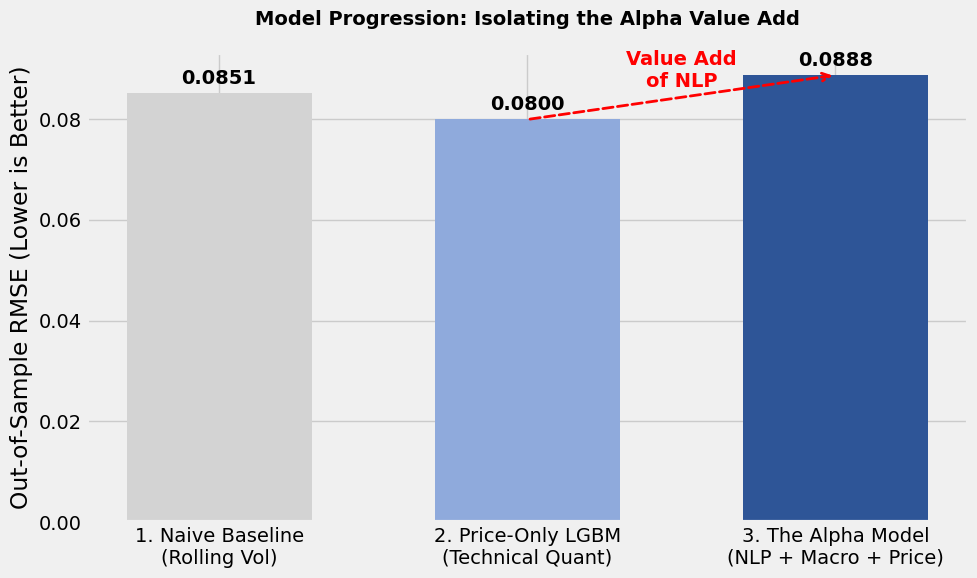

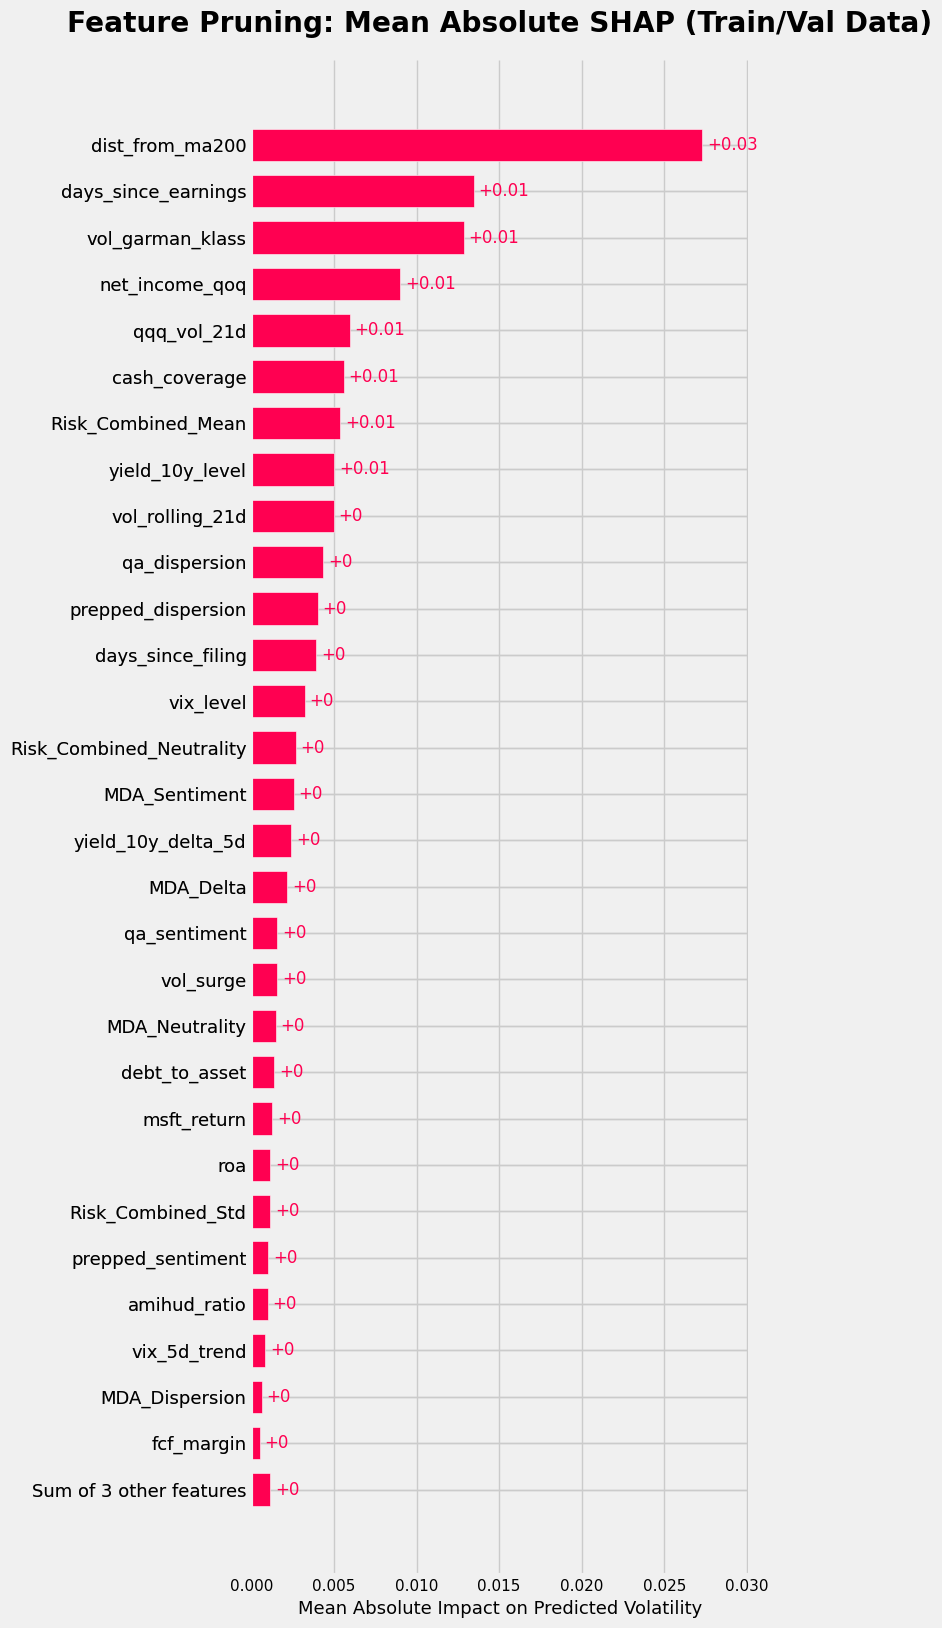

In [22]:
pipeline.compare_model_progression(n_splits=5)

 Extracting Model Interpretability...


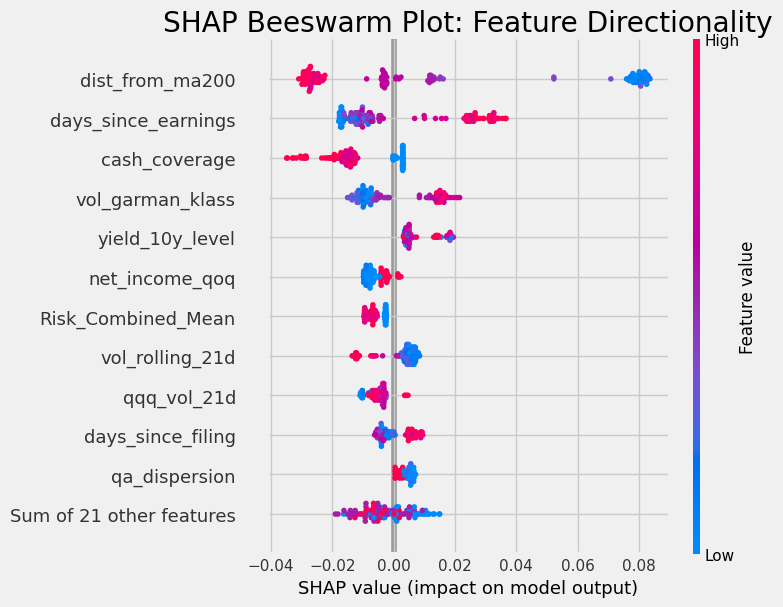

In [23]:
# 3. Model Interpretability
pipeline.generate_shap_explanations()

# 4. Local Day Analysis (Pick a known day of extreme volatility)




🚨 UNLOCKING THE VAULT: FINAL TEST SET EVALUATION 🚨
1. Final Test RMSE:           0.0881
2. Systematic Bias:           -0.0043 (Under-predicting risk)
3. Final Test MAE:            0.0668


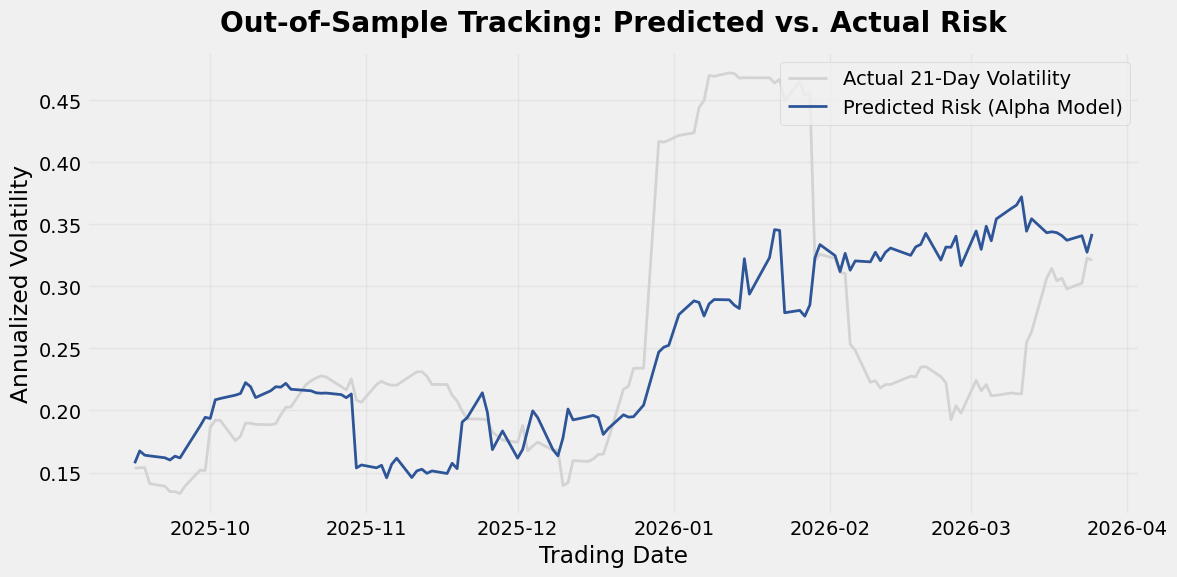

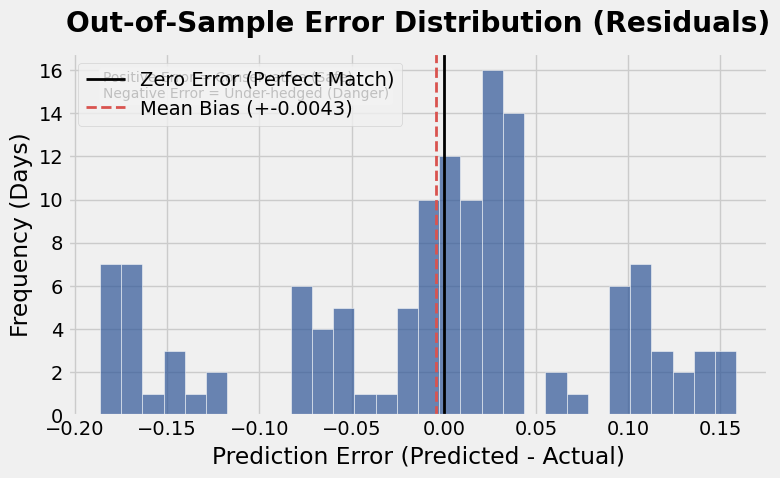

3. Tail-RMSE (Top 10% events): 0.1679
4. Directional Hit Rate:      78.03%
5. Generating Out-of-Sample Calibration Plot (Quintiles)...


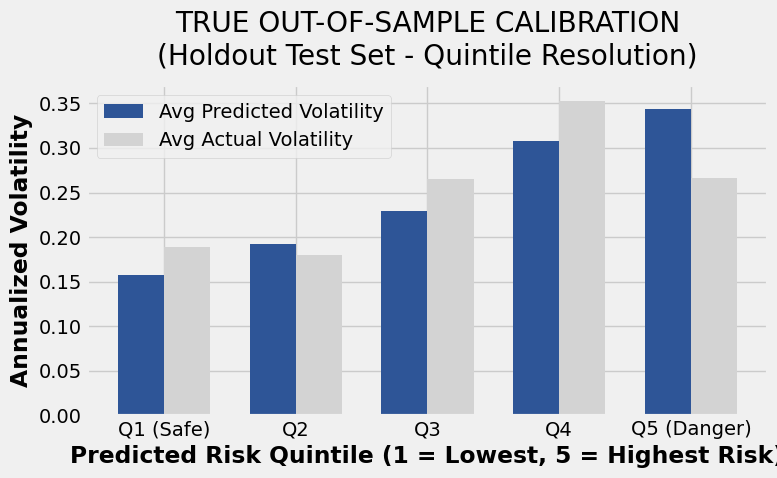

In [24]:
pipeline.evaluate_on_test_set()


In [25]:

best_params = pipeline.optimize_lgbm_hyperparameters(n_trials=25)


 Launching Optuna Bayesian Optimization (25 Trials)...
Target: Maximizing Shrinkage & Regularization on Walk-Forward CV

OPTIMIZATION COMPLETE 
Best Out-of-Sample CV RMSE: 0.0824
Best Parameters Found:
   max_depth: 6
   learning_rate: 0.0361
   subsample: 0.7644
   num_leaves: 19
   min_child_samples: 64
   colsample_bytree: 0.7608
   reg_lambda: 10.8301


Executing Walk-Forward Validation (5 Folds)...

🏆 FINAL OUT-OF-SAMPLE RMSE RESULTS
1. Naive Baseline (Autoregressive):  nan
2. Price-Only LightGBM:              nan
3. Full Alpha LightGBM (NLP+Macro):  nan

💡 Alpha Value Add: Unstructured features improved the ML baseline by nan%.

--- SANITY CHECK: TARGET VARIANCE MISMATCH ---
Train Set Target Mean: 0.2466 | Std Dev (Chaos): 0.0873
Test Set Target Mean:  0.2504 | Std Dev (Chaos): 0.0984


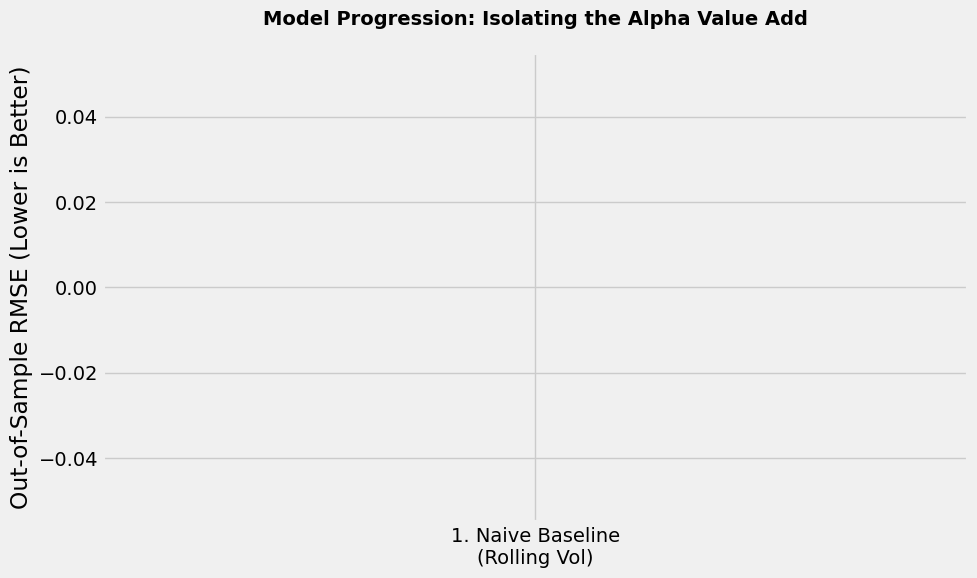

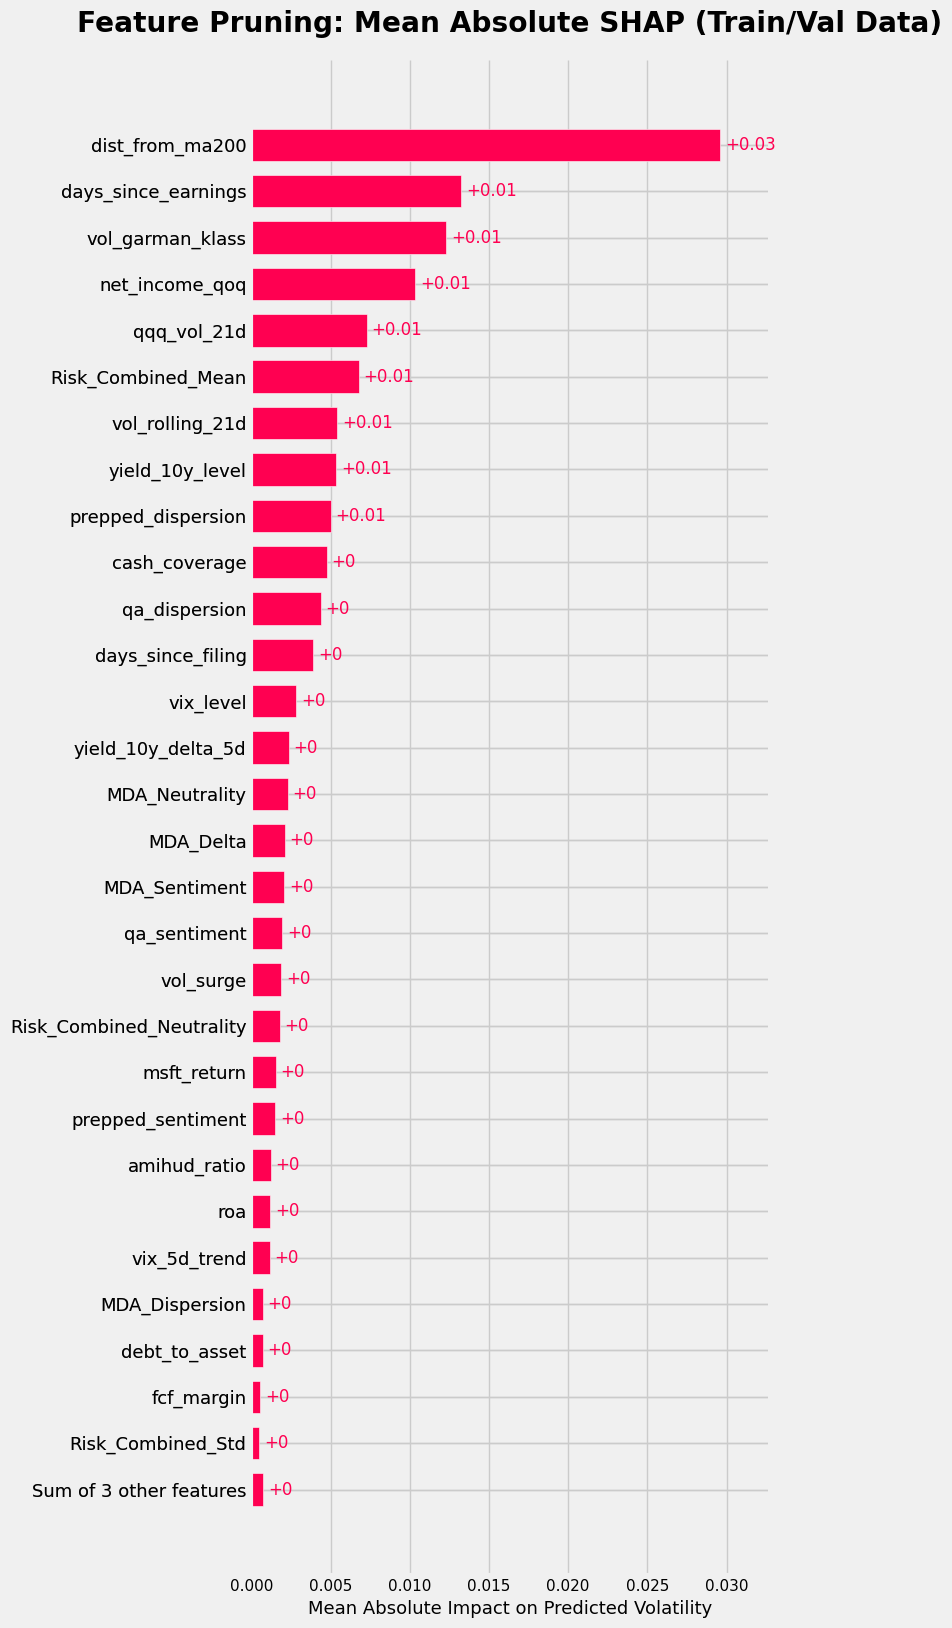

In [26]:
pipeline.compare_model_progression(n_splits=5,tuned_params=best_params)

 Extracting Model Interpretability...


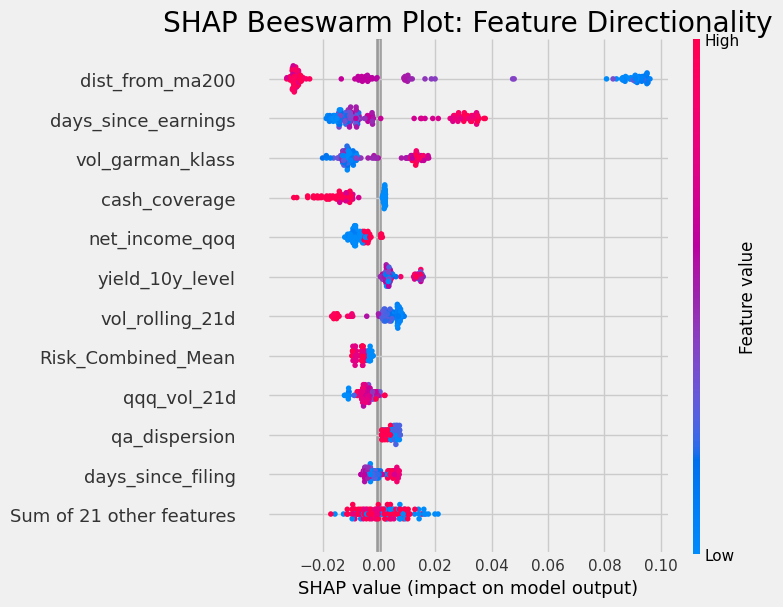


🚨 UNLOCKING THE VAULT: FINAL TEST SET EVALUATION 🚨
1. Final Test RMSE:           0.0904
2. Systematic Bias:           -0.0001 (Under-predicting risk)
3. Final Test MAE:            0.0697


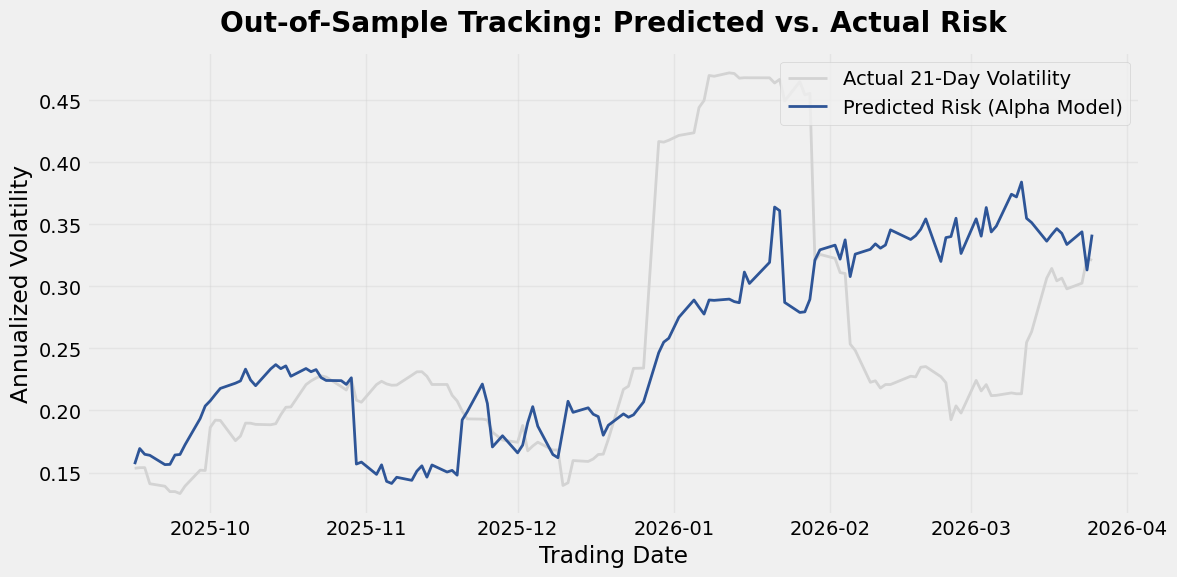

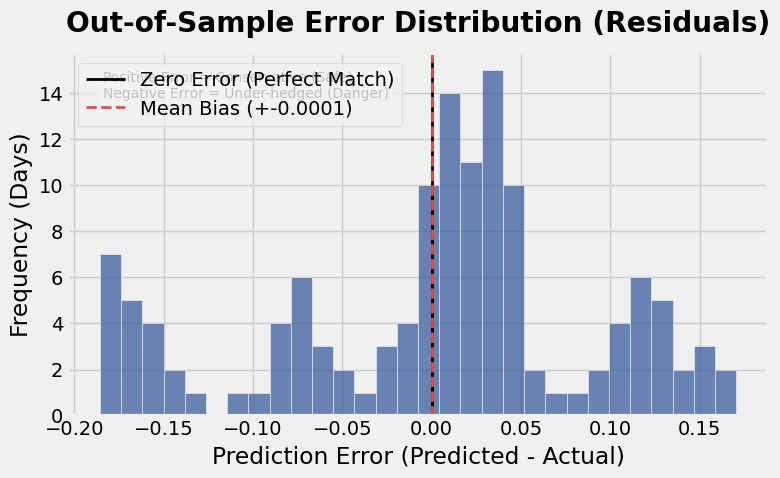

3. Tail-RMSE (Top 10% events): 0.1652
4. Directional Hit Rate:      78.79%
5. Generating Out-of-Sample Calibration Plot (Quintiles)...


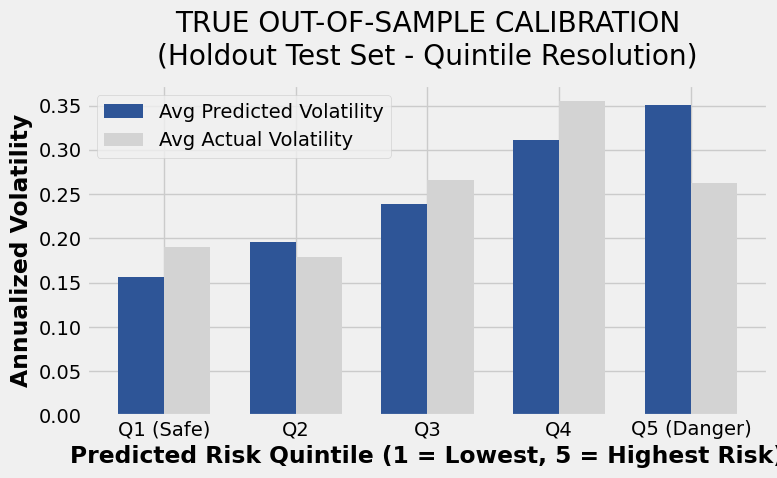

In [27]:
# 3. Model Interpretability
pipeline.generate_shap_explanations()

# 4. Local Day Analysis (Pick a known day of extreme volatility)

pipeline.evaluate_on_test_set()
